In [33]:
from upsetplot import UpSet, from_memberships, from_contents
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pysam
import numpy as np
from collections import Counter, defaultdict
import pyranges as pr
import itertools
import subprocess
import seaborn as sns

In [34]:
from src import make_a_plot, intersect

In [35]:
## generic variables

L1_families = ["L1HS", "L1PA2", "L1PA3", "L1PA6"]

regions = [
    "full_intergenic",
    "full_intronic",
    "truncate_intergenic",
    "truncate_intronic",
]

In [59]:
base_path = "../illumina_files/SGNex_MCF7_Illumina_replicate3_run1"
categories = [cat + "_L1HS" for cat in regions]
seperate_unique_multi = True
reads_path = "../illumina_files/SGNex_MCF7_Illumina_replicate3_run1/SGNex_MCF7_Illumina_replicate3_run1_unique_reads.txt"
illumina = True

In [60]:
if seperate_unique_multi:
    with open(reads_path, "r") as f:
        unique_reads = set(f.read().split())
unique_reads

{'K00151:464:H3HL2BBXY:2:1110:20649:24648',
 'K00151:464:H3HL2BBXY:3:1206:29406:36552',
 'K00151:464:H3HL2BBXY:2:1212:5923:14678',
 'K00151:464:H3HL2BBXY:3:1208:31294:38978',
 'K00151:464:H3HL2BBXY:3:2208:26504:33000',
 'K00151:464:H3HL2BBXY:2:2117:12256:26881',
 'K00151:464:H3HL2BBXY:2:1121:27833:29360',
 'K00151:464:H3HL2BBXY:3:1216:1438:22942',
 'K00151:464:H3HL2BBXY:2:2103:2534:33141',
 'K00151:464:H3HL2BBXY:2:1128:15493:4884',
 'K00151:464:H3HL2BBXY:3:2120:27549:15750',
 'K00151:464:H3HL2BBXY:3:1204:23389:32349',
 'K00151:464:H3HL2BBXY:3:2115:30787:17772',
 'K00151:464:H3HL2BBXY:2:1218:21775:32472',
 'K00151:464:H3HL2BBXY:2:2115:13078:36569',
 'K00151:464:H3HL2BBXY:2:2128:12550:2598',
 'K00151:464:H3HL2BBXY:2:2208:1600:20762',
 'K00151:464:H3HL2BBXY:3:2103:28189:29483',
 'K00151:464:H3HL2BBXY:2:2111:7172:49054',
 'K00151:464:H3HL2BBXY:2:1106:29457:37132',
 'K00151:464:H3HL2BBXY:2:1128:28341:43075',
 'K00151:464:H3HL2BBXY:3:1228:26880:13324',
 'K00151:464:H3HL2BBXY:3:2120:28726:245

In [61]:
ids = {}
# get list of read_ids for each sample
for cat in categories:
    # if bed file is empty
    if Path(f"{base_path}/{cat}.bed").stat().st_size == 0:
        continue

    if illumina:
        readIDs = set(
            pd.read_csv(f"{base_path}/{cat}.bed", sep="\t", header=None)[3]
            .str[:-2]
            .drop_duplicates()
            .to_list()
        )
    else:
        readIDs = set(
            pd.read_csv(f"{base_path}/{cat}.bed", sep="\t", header=None)[3]
            .drop_duplicates()
            .to_list()
        )

    # iterate through reads and determine if unique or not
    ids[cat + "_unique"] = []
    ids[cat + "_multi"] = []

    for read in readIDs:
        if read in unique_reads:
            ids[cat + "_unique"].append(read)
        else:
            ids[cat + "_multi"].append(read)

In [62]:
# get values that exist in ids['full_intergenic_L1HS_unique'] and ids['truncate_intergenic_L1HS_unique']
set(ids["full_intergenic_L1HS_unique"]).intersection(
    set(ids["truncate_intergenic_L1HS_unique"])
)

{'K00151:464:H3HL2BBXY:2:1202:6593:45555',
 'K00151:464:H3HL2BBXY:2:2104:2605:27918',
 'K00151:464:H3HL2BBXY:2:2204:18649:4796',
 'K00151:464:H3HL2BBXY:2:2206:10287:45273',
 'K00151:464:H3HL2BBXY:2:2211:32289:33422',
 'K00151:464:H3HL2BBXY:3:2116:24302:7275',
 'K00151:464:H3HL2BBXY:3:2124:31649:4884',
 'K00151:464:H3HL2BBXY:3:2224:22333:29044',
 'K00151:464:H3HL2BBXY:3:2227:7080:4690'}

In [67]:
## K00151:464:H3HL2BBXY:2:1202:6593:45555 in full length
df = pd.read_csv(f"{base_path}/full_intergenic_L1HS.bed", sep="\t", header=None)
df[df[3].str.contains("K00151:464:H3HL2BBXY:2:1202:6593:45555")]

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
1208,5,102131467,102131574,K00151:464:H3HL2BBXY:2:1202:6593:45555/2,255,+,102131467,102131574,"0,0,0",1,...,"0,",5,RepeatMasker,exon,102131357,102137385,.,+,.,"transcript_id ""L1HS_dup1065""; gene_id ""L1HS""; ..."


In [68]:
## K00151:464:H3HL2BBXY:2:1202:6593:45555 in truncated
df = pd.read_csv(f"{base_path}/truncate_intergenic_L1HS.bed", sep="\t", header=None)
df[df[3].str.contains("K00151:464:H3HL2BBXY:2:1202:6593:45555")]

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
2053,5,102189591,102189697,K00151:464:H3HL2BBXY:2:1202:6593:45555/1,255,-,102189591,102189697,"0,0,0",1,...,"0,",5,RepeatMasker,exon,102189484,102194435,.,+,.,"transcript_id ""L1HS_dup1066""; gene_id ""L1HS""; ..."


## SGNex MCF-7

In [75]:
path = "../illumina_files/SGNex_MCF7_Illumina_replicate3_run1"
readspath = "../illumina_files/SGNex_MCF7_Illumina_replicate3_run1/SGNex_MCF7_Illumina_replicate3_run1_unique_reads.txt"

/netapp/LOG-G4/jfaybishenko/bulk_te_bench/analysis/upset/src.py:92: DtypeWarning: Columns (0,12) have mixed types. Specify dtype option on import or set low_memory=False.
  readIDs = set(pd.read_csv(f"{base_path}/{cat}.bed", sep="\t", header=None)[3].str[:-2].drop_duplicates().to_list())


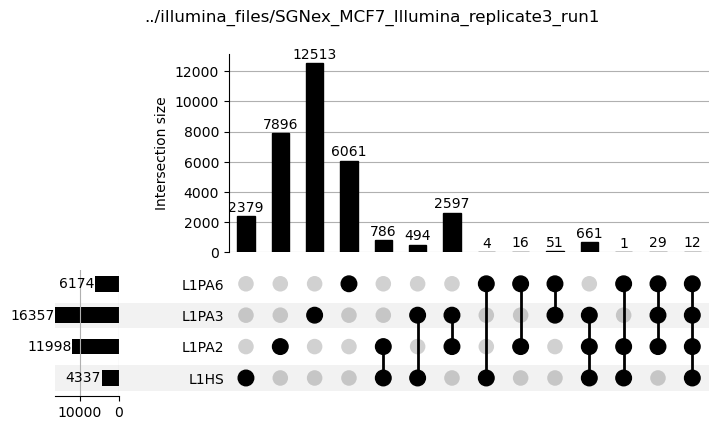

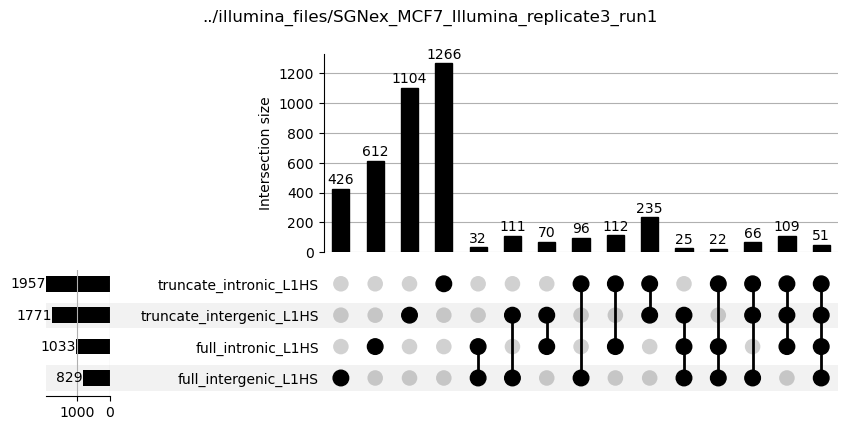

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [76]:
make_a_plot(path, categories=L1_families, illumina=True)
make_a_plot(path, categories=[cat + "_L1HS" for cat in regions], illumina=True)

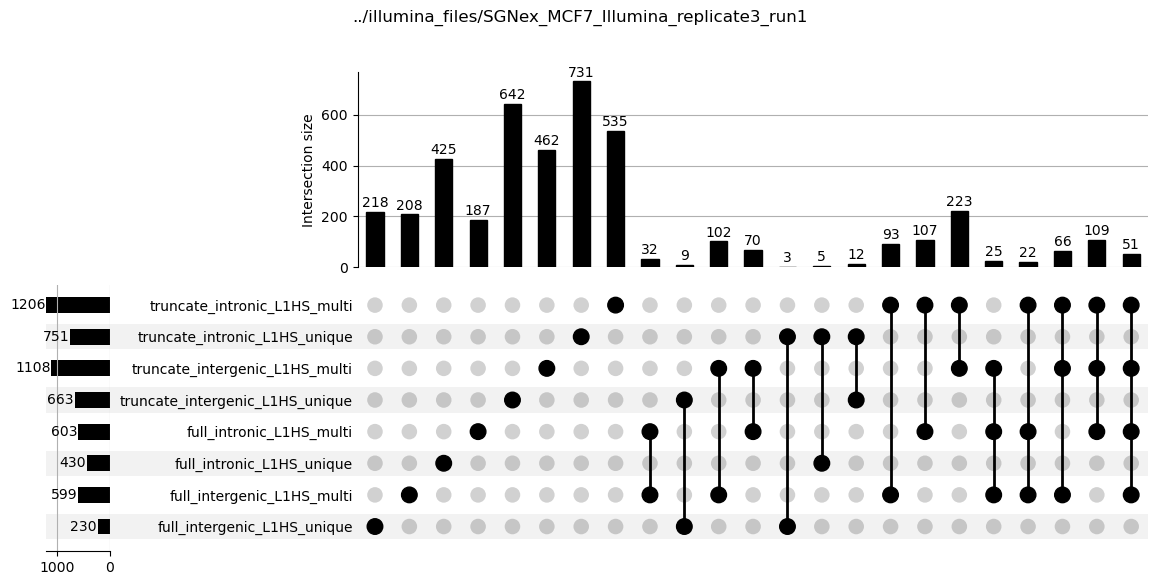

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [77]:
make_a_plot(
    path,
    categories=[cat + "_L1HS" for cat in regions],
    seperate_unique_multi=True,
    reads_path=readspath,
    illumina=True,
)

## Generated Genome Aligned MCF-7 

In [18]:
path = "../illumina_files/mikes_files/genome/SGNex_MCF7_Illumina_replicate3_run1"
readspath = "../illumina_files/mikes_files/genome/SGNex_MCF7_Illumina_replicate3_run1/unique_reads.txt"

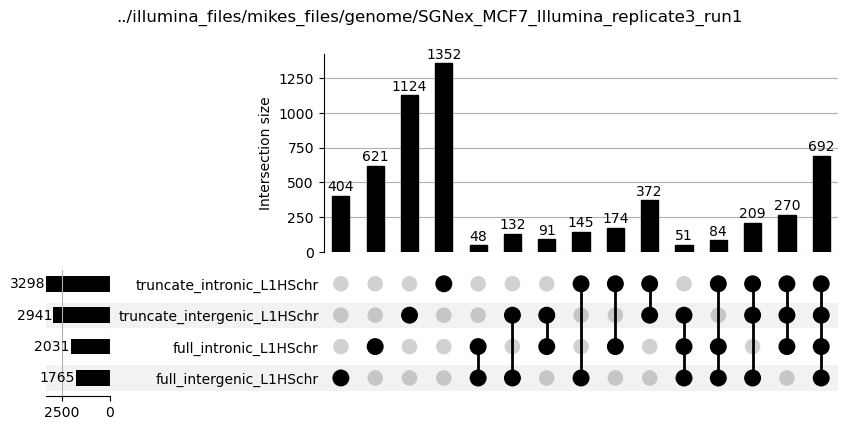

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [19]:
make_a_plot(path, categories=[cat + "_L1HSchr" for cat in regions], illumina=True)

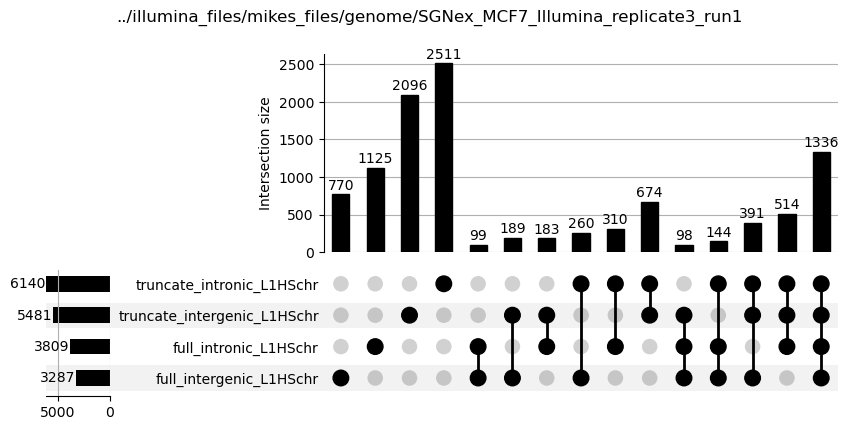

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [20]:
make_a_plot(path, categories=[cat + "_L1HSchr" for cat in regions], illumina=False)

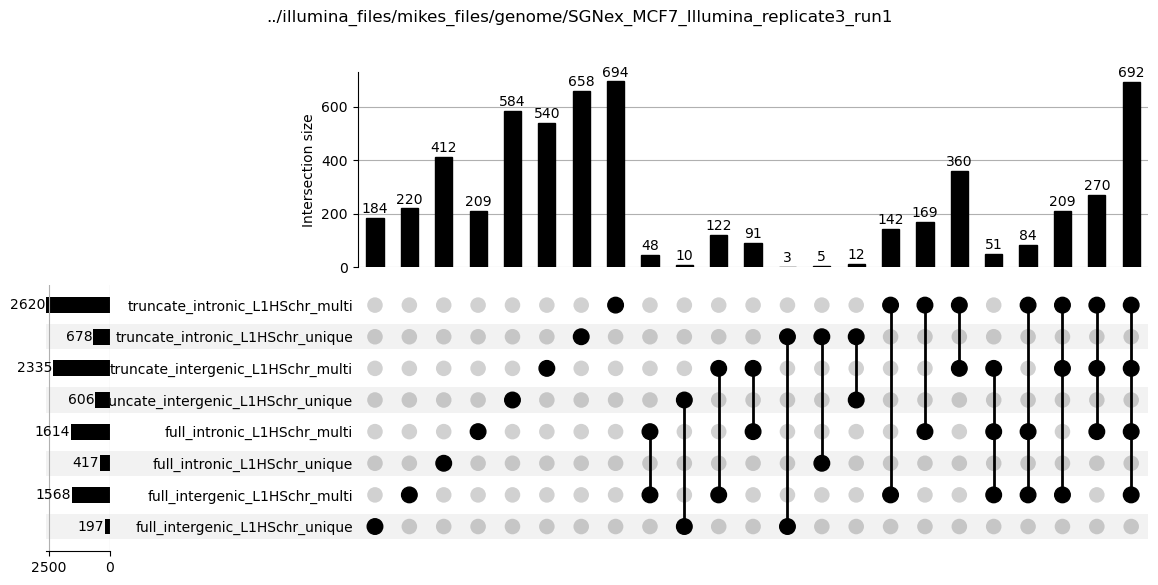

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [21]:
make_a_plot(
    path,
    categories=[cat + "_L1HSchr" for cat in regions],
    seperate_unique_multi=True,
    reads_path=readspath,
    illumina=True,
)

## Generated Txome Aligned MCF-7 

In [72]:
path = "../illumina_files/mikes_files/txome/SGNex_MCF7_Illumina_replicate3_run1"
bamfile = "../illumina_files/mikes_files/star_align/SGNex_MCF7_Illumina_replicate3_run1/Aligned.toTranscriptome.out.bam"
readspath = "../illumina_files/mikes_files/txome/SGNex_MCF7_Illumina_replicate3_run1/unique_reads.txt"

In [10]:
for subfamily in ["L1PA2", "L1PA3", "L1PA6"]:
    intersect(bamfile, subfamily, path)

[E::idx_find_and_load] Could not retrieve index file for '../illumina_files/mikes_files/star_align/SGNex_MCF7_Illumina_replicate3_run1/Aligned.toTranscriptome.out.bam'
[E::idx_find_and_load] Could not retrieve index file for '../illumina_files/mikes_files/star_align/SGNex_MCF7_Illumina_replicate3_run1/Aligned.toTranscriptome.out.bam'
[E::idx_find_and_load] Could not retrieve index file for '../illumina_files/mikes_files/star_align/SGNex_MCF7_Illumina_replicate3_run1/Aligned.toTranscriptome.out.bam'
[E::idx_find_and_load] Could not retrieve index file for '../illumina_files/mikes_files/star_align/SGNex_MCF7_Illumina_replicate3_run1/Aligned.toTranscriptome.out.bam'


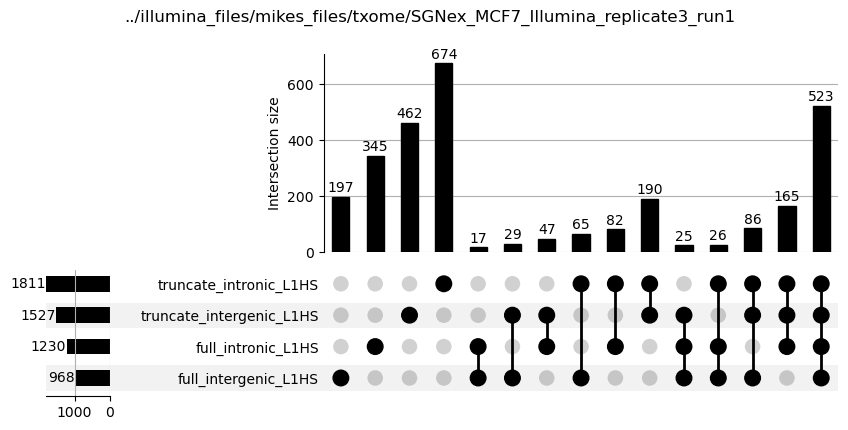

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [73]:
# make_a_plot(path, categories=[], illumina=True)
make_a_plot(path, categories=[cat + "_L1HS" for cat in regions], illumina=True)

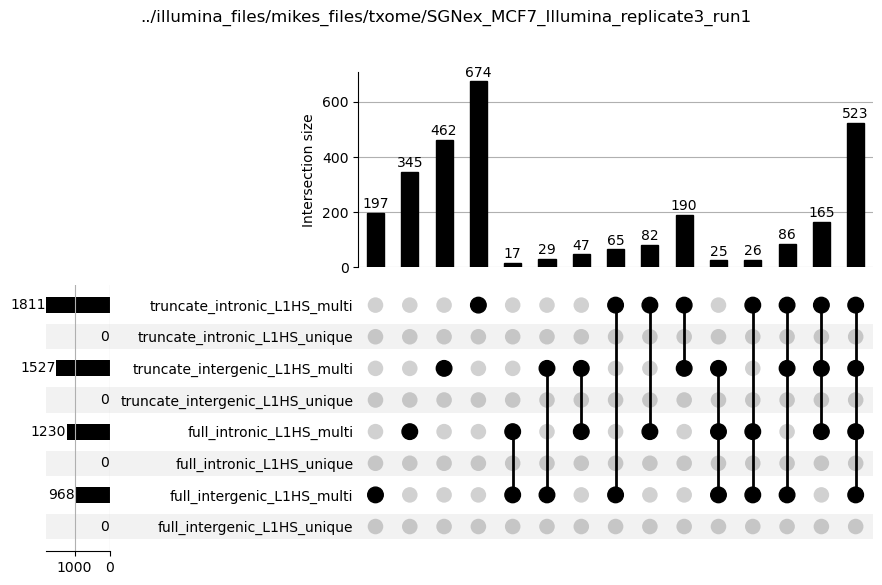

<module 'matplotlib.pyplot' from '/raidixshare_logg01/jfaybishenko/mambaforge/envs/new_bulk/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [74]:
make_a_plot(
    path,
    categories=[cat + "_L1HS" for cat in regions],
    seperate_unique_multi=True,
    reads_path=readspath,
    illumina=True,
)